In [148]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import gmsh
# import openseespy.postprocessing.Get_Rendering as opsplt

In [149]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [150]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to C:\Users\Michael 
Ocampo\Documents\mini\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [151]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (162847303444)>


In [152]:
# step_rectangle_trapezoid_fragment_fixed.py
import gmsh

# --- Initialize Gmsh ---
gmsh.initialize()
gmsh.model.add("rectangle_trapezoid_fragment")
occ = gmsh.model.occ

# --- Geometry ---
rect1 = occ.addRectangle(0, 0, 0, 40, 5)
rect2 = occ.addRectangle(40, 0, 0, 20, 5)

p1 = occ.addPoint(0, 5, 0)
p2 = occ.addPoint(40, 5, 0)
p3 = occ.addPoint(20, 15, 0)
p4 = occ.addPoint(0, 15, 0)

l1 = occ.addLine(p1, p2)
l2 = occ.addLine(p2, p3)
l3 = occ.addLine(p3, p4)
l4 = occ.addLine(p4, p1)

trap_loop = occ.addCurveLoop([l1, l2, l3, l4])
trap_surf = occ.addPlaneSurface([trap_loop])

occ.synchronize()

# --- Fragment all together ---
occ.fragment([(2, rect1), (2, rect2)], [(2, trap_surf)])
occ.removeAllDuplicates()
occ.synchronize()

# --- Get surface tags ---
surfs = [tag for dim, tag in gmsh.model.getEntities(2)]

# --- Transfinite mesh: surface 1 ---
bound1 = gmsh.model.getBoundary([(2, surfs[0])], oriented=False)
curves1 = [b[1] for b in bound1]
gmsh.model.mesh.setTransfiniteCurve(curves1[0], 20)
gmsh.model.mesh.setTransfiniteCurve(curves1[1], 10)
gmsh.model.mesh.setTransfiniteCurve(curves1[2], 20)
gmsh.model.mesh.setTransfiniteCurve(curves1[3], 10)
gmsh.model.mesh.setTransfiniteSurface(surfs[0])
gmsh.model.mesh.setRecombine(2, surfs[0])

# --- Transfinite mesh: surface 2 ---
bound2 = gmsh.model.getBoundary([(2, surfs[1])], oriented=False)
curves2 = [b[1] for b in bound2]
gmsh.model.mesh.setTransfiniteCurve(curves2[0], 10)
gmsh.model.mesh.setTransfiniteCurve(curves2[1], 20)
gmsh.model.mesh.setTransfiniteCurve(curves2[2], 10)
gmsh.model.mesh.setTransfiniteCurve(curves2[3], 20)
gmsh.model.mesh.setTransfiniteSurface(surfs[1])
gmsh.model.mesh.setRecombine(2, surfs[1])

# --- Transfinite mesh: surface 3 ---
bound3 = gmsh.model.getBoundary([(2, surfs[2])], oriented=False)
curves3 = [b[1] for b in bound3]
gmsh.model.mesh.setTransfiniteCurve(curves3[0], 20)
gmsh.model.mesh.setTransfiniteCurve(curves3[1], 20)
gmsh.model.mesh.setTransfiniteCurve(curves3[2], 20)
gmsh.model.mesh.setTransfiniteCurve(curves3[3], 20)
gmsh.model.mesh.setTransfiniteSurface(surfs[2])
gmsh.model.mesh.setRecombine(2, surfs[2])

#p5 = occ.addPoint(4.21, 15.249, 0)
#p6 = occ.addPoint(15.78, 15.249, 0)
#l5 = occ.addLine(p5, p6)
#gmsh.model.occ.synchronize()
#gmsh.model.mesh.setTransfiniteCurve(11, 12)

# --- Physical lines ---
# --- Line Physical Groups ---
gmsh.model.addPhysicalGroup(1, [1], tag=201)
gmsh.model.setPhysicalName(1, 201, "bottom_support_a")

gmsh.model.addPhysicalGroup(1, [5], tag=202)
gmsh.model.setPhysicalName(1, 202, "bottom_support_b")

gmsh.model.addPhysicalGroup(1, [4], tag=203)
gmsh.model.setPhysicalName(1, 203, "left_bot_support")

gmsh.model.addPhysicalGroup(1, [6], tag=204)
gmsh.model.setPhysicalName(1, 204, "right_bot_support")

gmsh.model.addPhysicalGroup(1, [10], tag=205)
gmsh.model.setPhysicalName(1, 205, "left_top_support")

gmsh.model.addPhysicalGroup(1, [9], tag=206)
gmsh.model.setPhysicalName(1, 206, "loadings")

gmsh.model.addPhysicalGroup(2, [1], 301)
gmsh.model.setPhysicalName(2, 301, "soil_bot_a")

gmsh.model.addPhysicalGroup(2, [2], 302)
gmsh.model.setPhysicalName(2, 302, "soil_bot_b")

gmsh.model.addPhysicalGroup(2, [3], 303)
gmsh.model.setPhysicalName(2, 303, "soil_top")

gmsh.model.addPhysicalGroup(1, [11], tag=304)
gmsh.model.setPhysicalName(1, 304, "beam")

# Get coordinates for a specific node ID
#node_tag = 137  # replace with your actual node tag
#node_coords = gmsh.model.mesh.getNode(node_tag)[0]  # returns (x, y, z)
#print(f"Node {node_tag} coordinates: {node_coords}")

# --- Finalize mesh ---
gmsh.model.occ.synchronize()
gmsh.model.mesh.generate(2)
gmsh.write("slope_stability_fixed.msh")
#gmsh.fltk.run()
#gmsh.finalize()


In [153]:
GMSH2OPS = opst.pre.Gmsh2OPS(ndm=2, ndf=2)
GMSH2OPS.read_gmsh_file("slope_stability_fixed.msh")
gmsh.finalize()

Info:: 10 Physical Names.
Info:: 770 Nodes; MaxNodeTag 770; MinNodeTag 1.
Info:: 797 Elements; MaxEleTag 797; MinEleTag 1.
Info:: Geometry Information >>>
21 Entities: 8 Point; 10 Curves; 3 Surfaces; 0 Volumes.

Info:: Physical Groups Information >>>
9 Physical Groups.
Physical Group names: ['bottom_support_a', 'left_bot_support', 'bottom_support_b', 'right_bot_support', 'loadings', 'left_top_support', 'soil_bot_a', 'soil_bot_b', 'soil_top']

Info:: Mesh Information >>>
770 Nodes; MaxNodeTag 770; MinNodeTag 1.
797 Elements; MaxEleTag 797; MinEleTag 1.



In [154]:
GMSH2OPS.get_physical_groups()

{'bottom_support_a': [(1, 1)],
 'left_bot_support': [(1, 4)],
 'bottom_support_b': [(1, 5)],
 'right_bot_support': [(1, 6)],
 'loadings': [(1, 9)],
 'left_top_support': [(1, 10)],
 'soil_bot_a': [(2, 1)],
 'soil_bot_b': [(2, 2)],
 'soil_top': [(2, 3)]}

In [155]:
ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 3)

In [156]:
fmass = 1.0  # fluid mass density
smass = 2.0  # saturated soil mass density
G = 6.0e4
B = 2.4e5
bulk = 2.2e6  # fluid-solid combined bulk modulus
vperm = 5.0e-4  # vertical permeability (m/s)
hperm = 5.0e-4  # horizontal permeability (m/s)
accGravity = 9.81  # acceleration of gravity

# Actual values used in computation
vperm = vperm / accGravity / fmass
hperm = hperm / accGravity / fmass

press = 0.0  # isotropic consolidation pressure on quad element(s)
loadBias = 0.07  # Static shear load, in percentage of gravity load

accMul = 2.0  # acc. multiplier
accNam = "whatever.acc"  # file name for input acc. record
accDt = 0.0166  # dt of input acc. record
period = 1.0  # Period for applied Sine wave
deltaT = 0.01  # time step for analysis
numSteps = 2400  # number of time steps
gamma = 0.6  # Newmark integration parameter

massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.002

numXele = 1  # number of elements in x (H) direction
numYele = 10  # number of elements in y (V) direction
xSize = 1.0  # x direction element size
ySize = 1.0  # y direction element size


refshearModul = 6e4
rho = 1.8
refbulk = 3e5
frictionAngle = 30
cohesion = 30
peakShearStrain = 0.1
refPressure = 0
pressDependent = 0
noYieldSurf = 20

gravY = -accGravity  # calc. gravity
gravX = -gravY * loadBias

soil_mattag = 1

In [157]:
ops.nDMaterial("PressureDependMultiYield", soil_mattag, 2, smass, G, B, 31.4, 0.1, 80, 0.5, 26.5, 0.1, 0.2, 5, 10, 0.015, 1.0)

soil_Fill_mat_tag = 1
#ops.nDMaterial("InitialStateAnalysisWrapper", soil_Fill_mat_tag, soil_mattag, 2)
#ops.nDMaterial('FluidSolidPorous', soil_Fill_mat_tag, 2, soil_mattag, 2.2e6)

In [158]:
GMSH2OPS.create_node_cmds()
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"
rho_d = 0.0

soil_groups = [
    "soil_bot_a",
    "soil_bot_b",
    "soil_top"
]
#               thick,
element_args = [ 1.0, soil_mattag, bulk, fmass, hperm, vperm, gravX, gravY, press] # press, rho_d, unitWeightX, unitWeightY

# Create elements for each soil group
for group_name in soil_groups:
    ele_tags = GMSH2OPS.create_element_cmds(
        ops_ele_type="quadUP",
        ops_ele_args=element_args,
        physical_group_names=[group_name]
    )

In [159]:
node_id = 137
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")
node_id = 126
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")

Node 137 coordinate: [4.210526315789473, 15.0]
Node 126 coordinate: [15.78947368421053, 15.0]


In [160]:
ops.model("basic", "-ndm", 2, "-ndf", 3)

start_N_id = SF.get_next_node_id(start_from=None)

In [161]:
pad_foundation_coor = [
[20.0000 , 15.0],
[18.9482 , 15.0],
[17.8964 , 15.0],
[16.8445 , 15.0],
[15.7927 , 15.0],
[14.7409 , 15.0],
[13.6891 , 15.0],
[12.6373 , 15.0],
[11.5855 , 15.0],
[10.5336 , 15.0],
[ 9.4818 , 15.0],
[ 8.4300 , 15.0],
]

pad_noodes = SF.add_nodes_from_coordinates(coord_list = pad_foundation_coor, start_id = start_N_id, block_name = "pad_nodes")

In [162]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.3)
print(Iz)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.5*UNIT.m2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAMs = SF.create_disp_beam_column_chain(beam_nodes = pad_noodes, beam_start_id = 1001,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

0.00225


In [163]:
print(BEAMs)
lining_slave_nodes = [7,123,124,124,125,126,127,128,129,130,131,132]

[1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011]


In [164]:
pad_soil = SF.apply_equal_dof_pairs(r_nodes = pad_noodes, c_nodes = lining_slave_nodes , dofs=[1, 2], block_name="equal_dof_pairs")

In [165]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [166]:
fixXY = [1, 1, 0]
fixXonly = [1, 0, 0]
fixYonly = [0, 1, 0]

In [167]:
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_a"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_b"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_bot_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_top_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["right_bot_support"], dofs=fixXonly)
ops.fix(4, *fixXonly)
ops.fix(8, *fixXonly)
ops.fix(6, *fixXonly)
ops.fix(1, *fixXY)
ops.fix(2, *fixXY)
ops.fix(5, *fixXY)

In [168]:
loading_nodes = GMSH2OPS.get_node_tags(physical_group_names="loadings")
print(loading_nodes)

[123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140]


In [169]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [170]:
import openseespy.opensees as ops
import opstool as opst
import opstool.vis.plotly as opsvis

In [171]:
ops.updateMaterialStage('-material', soil_Fill_mat_tag, '-stage', 0)
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1.0e-8, 30, 0)
ops.algorithm("KrylovNewton")
ops.constraints("Penalty", 1.e18, 1.e18)
ops.integrator("Newmark", 1.5, (1.5 + 0.5) ** 2 / 4)
ops.analysis("Transient")
ops.analyze(10, 5e3)
ops.updateMaterialStage('-material', soil_Fill_mat_tag, '-stage', 1)


after: 30 iterations  current Norm: 8.88203e-07 (max: 1e-08, Norm deltaR: 1.75954)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 5000
OpenSees > analyze failed, returned: -3 error flag


In [172]:
ops.wipeAnalysis()
ops.setTime(0.0)
 
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
for bb in BEAMs:
    opst.pre.transform_beam_uniform_load(bb, wy=-75.0)

opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = True, show_ele_loads=True)

In [173]:

# DYNAMIC ANALYSIS
ops.constraints("Penalty", 1.e18, 1.e18)
ops.test("NormDispIncr", 1.e-4, 25, 0)
ops.numberer("RCM")
ops.algorithm("KrylovNewton")
ops.system("ProfileSPD")
ops.integrator("Newmark", gamma, (gamma + 0.5)**2 / 4)
ops.rayleigh(massProportionalDamping, 0.0, InitStiffnessProportionalDamping, 0.0)
ops.analysis("VariableTransient")

node_list = [437, 3, 112, 118, 122]
ops.recorder('Node', '-file', 'zyydisp1.out', '-time', '-node', *node_list, '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'zyyacce1.out', '-time', '-node', *node_list, '-dof', 1, 2, '-dT', 0.01, 'accel')
#ops.recorder('Element', '-ele', 437, '-time', '-file', 'zzstress1.out', '-dT', 0.01, 'material', 1, 'stress')
# ops.recorder('Element', '-ele', 437, '-time', '-file', 'zzstrain1.out', '-dT', 0.01, 'material', 1, 'strain')
# ops.recorder('Element', '-ele', 437, '-time', '-file', 'zzpress1.out', '-dT', 0.01, 'material', 1, 'pressure')
# ops.recorder('Element', '-ele', 569, '-time', '-file', 'zzstress569_1.out', '-dT', 0.01, 'material', 1, 'stress')
# ops.recorder('Element', '-ele', 569, '-time', '-file', 'zzstrain569_1.out', '-dT', 0.01, 'material', 1, 'strain')
# ops.recorder('Element', '-ele', 569, '-time', '-file', 'zzpress569_1.out', '-dT', 0.01, 'material', 1, 'pressure')
# ops.recorder('Element', '-ele', 569, '-time', '-file', 'zzstress569_3.out', '-dT', 0.01, 'material', 3, 'stress')
# ops.recorder('Element', '-ele', 569, '-time', '-file', 'zzstrain569_3.out', '-dT', 0.01, 'material', 3, 'strain')
# ops.recorder('Element', '-ele', 569, '-time', '-file', 'zzpress569_3.out', '-dT', 0.01, 'material', 3, 'pressure')
# ops.recorder('Element', '-ele', 492, '-time', '-file', 'zzstress492_1.out', '-dT', 0.01, 'material', 1, 'stress')
# ops.recorder('Element', '-ele', 492, '-time', '-file', 'zzstrain492_1.out', '-dT', 0.01, 'material', 1, 'strain')
# ops.recorder('Element', '-ele', 492, '-time', '-file', 'zzpress492_1.out', '-dT', 0.01, 'material', 1, 'pressure')

elements = [
    (436, [1]),       # element 437, material point 1
    (437, [1, 3]),    # element 569, material points 1 and 3
    (492, [1])        # element 492, material point 1
]

outputs = ["stress", "strain", "pressure"]

for ele_id, mat_ids in elements:
    for mat_id in mat_ids:
        for output in outputs:
            filename = f"zyy{output}{ele_id}_{mat_id}.out"
            ops.recorder(
                'Element', '-ele', ele_id, '-time',
                '-file', filename, '-dT', 0.01,
                'material', mat_id, output
            )


ODB = opst.post.CreateODB(
    odb_tag="Slope_PDMY09",
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
startT = tt.time()

deltaT = 0.010
numSteps = 1
repeat_count = 1000   # Number of repetitions
for _ in range(repeat_count):
    ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 10)
    ODB.fetch_response_step()

endT = tt.time()

print(f"Execution time: {endT - startT} seconds")

# Wipe model
ODB.save_response(zlib=True)
ops.wipe()


after: 25 iterations  current Norm: 0.000427794 (max: 0.0001, Norm deltaR: 5.22991)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.00515097 (max: 0.0001, Norm deltaR: 4.61104)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.000241347 (max: 0.0001, Norm deltaR: 4.77485)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.000183498 (max: 0.0001, Norm deltaR: 15.3324)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.00329147 (max: 0.0001, Norm deltaR: 17.649)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.00048662 (max: 0.0001, Norm deltaR: 15.2475)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
af

Execution time: 4466.350597858429 seconds


OPSTOOL ::  All responses data with _odb_tag = Slope_PDMY09 saved in .opstool.output/RespStepData-Slope_PDMY09.nc!

In [174]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [175]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Slope_PDMY09.nc ...

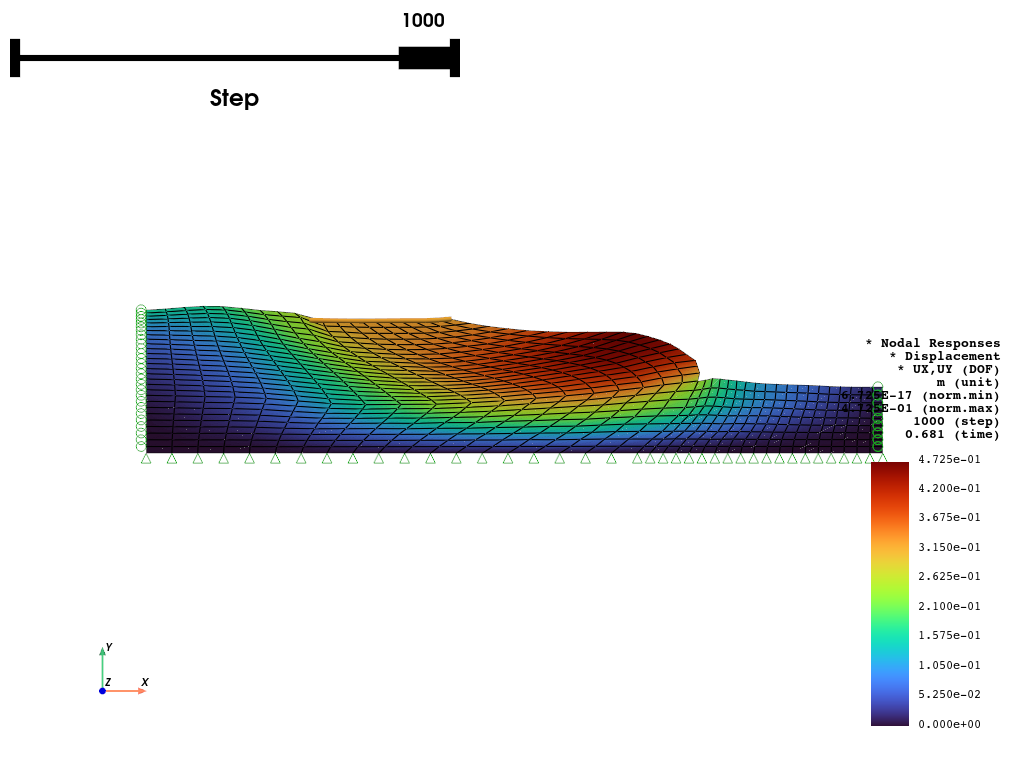

In [176]:
opsvis.plot_nodal_responses(
    odb_tag="Slope_PDMY09",
    slides=True,
    defo_scale=20,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Slope_PDMY09.nc ...

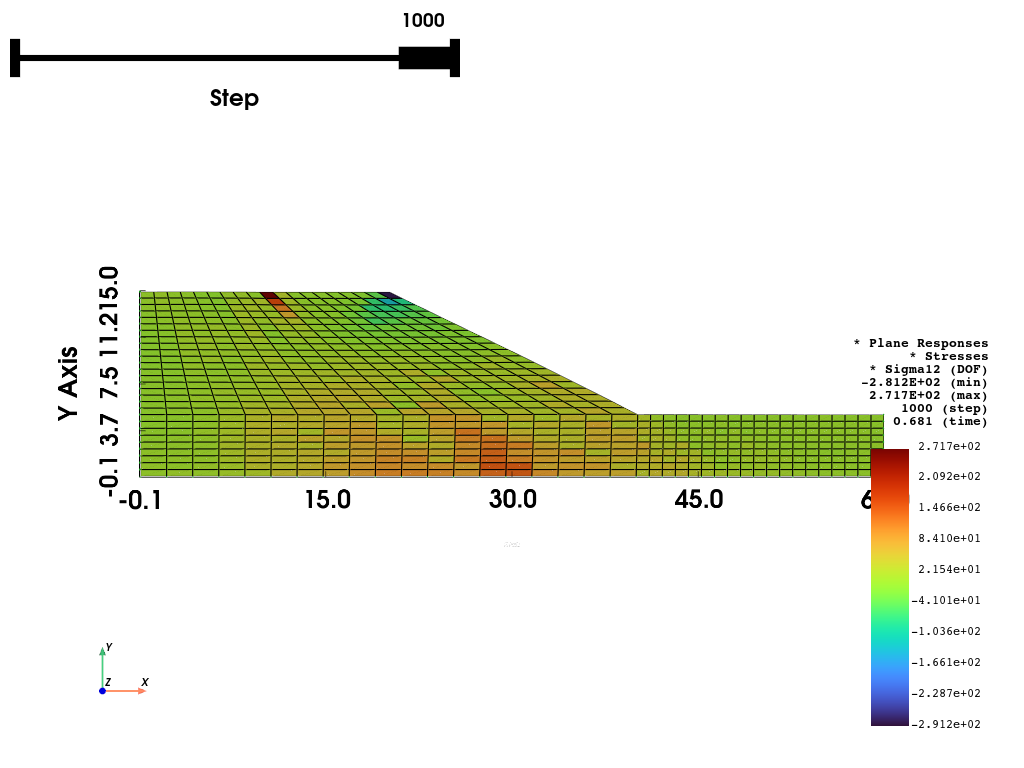

In [177]:
pl = opsvis.plot_unstruct_responses(
    odb_tag="Slope_PDMY09", slides=True, ele_type="Plane", resp_type="stresses", resp_dof="sigma12",
    show_defo = True,
    defo_scale = 0.5,
    show_bc = True,
    bc_scale = 0.1,
    show_outline = True,
    show_model = True,
)
pl.show(jupyter_backend="jupyterlab")

In [202]:
ele_resp = opst.post.get_element_responses(odb_tag="Slope_PDMY09", ele_type="Plane")
print("Data Variables in Element Responses:", ele_resp.data_vars)

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-Slope_PDMY09.nc ...

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 56MB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 34MB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 15MB 0.0 ... ...
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 9MB 0.0 ... 0...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 15MB 0.0 ... 0.0
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 9MB 0.0 ... 0.0
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 45MB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 45MB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 12MB 0.0 ... 154.9
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 12MB 0.0 ... 0....


In [203]:
print(ele_resp.stressDOFs.data)
print(ele_resp.strainDOFs.data)
print(ele_resp.measures.data)

['sigma11' 'sigma22' 'sigma12' 'sigma33' 'eta_r']
['eps11' 'eps22' 'eps12']
['p1' 'p2' 'sigma_vm' 'tau_max']


In [204]:
node_check = 292

In [205]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=node_check)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=node_check)
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=node_check)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=node_check)
eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=node_check)


In [206]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 4)> Size: 16kB
array([[ 0.        ,  0.        ,  0.        ,  0.        ],
       [-0.03115833, -0.03824267, -0.04013076, -0.03358505],
       [-0.23936754, -0.23900878, -0.24041629, -0.24041632],
       ...,
       [ 0.35324568,  4.3569627 ,  1.3476198 , 11.594616  ],
       [ 0.35324568,  4.3569627 ,  1.3476198 , 11.594616  ],
       [ 0.35324568,  4.3569627 ,  1.3476198 , 11.594616  ]],
      shape=(1001, 4), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.01 0.02 0.03 ... 0.6809 0.6809 0.6809
    eleTags      int64 8B 292
  * GaussPoints  (GaussPoints) int64 32B 1 2 3 4
    stressDOFs   <U7 28B 'sigma12'


In [207]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=node_check)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=node_check)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=node_check)

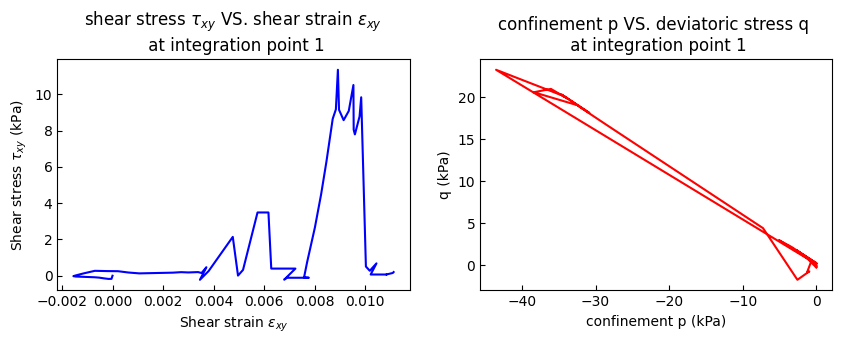

In [208]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [209]:
node_resp = opst.post.get_nodal_responses(odb_tag="Slope_PDMY09")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-Slope_PDMY09.nc ...

<xarray.Dataset> Size: 116MB
Dimensions:             (time: 1001, nodeTags: 782, DOFs: 6)
Coordinates:
  * time                (time) float32 4kB 0.0 0.01 0.02 ... 0.6809 0.6809
  * nodeTags            (nodeTags) int64 6kB 1 2 3 4 5 6 ... 778 779 780 781 782
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 19MB 0.0 ... -0.001036
    vel                 (time, nodeTags, DOFs) float32 19MB 0.0 ... -0.0008074
    accel               (time, nodeTags, DOFs) float32 19MB 0.0 0.0 ... 2.274
    reaction            (time, nodeTags, DOFs) float32 19MB -0.4016 ... 0.01383
    reactionIncInertia  (time, nodeTags, DOFs) float32 19MB -0.4016 ... -1.05...
    rayleighForces      (time, nodeTags, DOFs) float32 19MB 0.0 0.0 ... -0.01383
    pressure            (time, nodeTags) float32 3MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
  

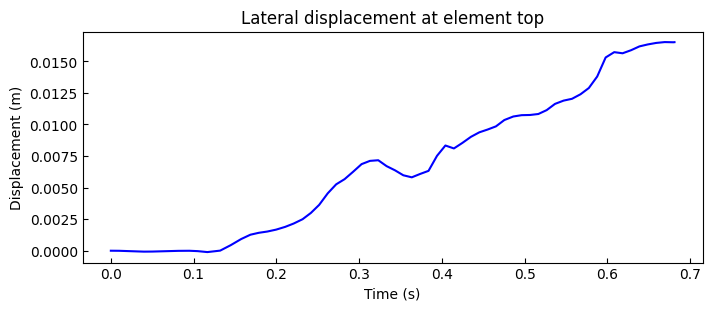

In [210]:
disp1 = node_resp["disp"].sel(nodeTags=108, DOFs="UX")
disp3 = node_resp["disp"].sel(nodeTags=107, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp1 - disp3 , "b") #- disp1
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

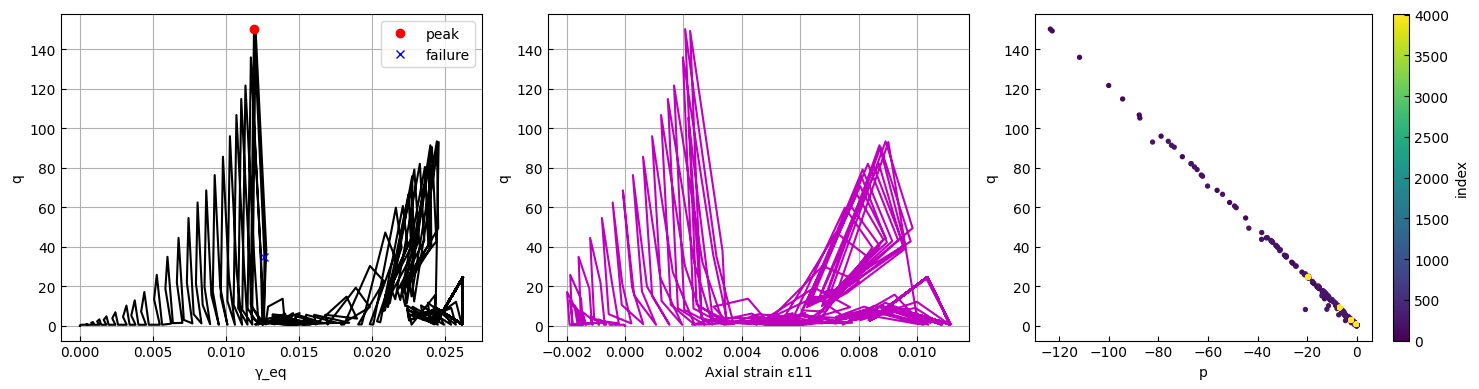

In [211]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional

s11 = sigma11
s22 = sigma22
s33 = sigma33
s12 = sigma12

e11 = eps11
e22 = eps22
e12 = eps12

def trim_to_same_length(*arrays):
    arrays_np = [np.ravel(np.asarray(a)) for a in arrays]
    min_len = min(len(a) for a in arrays_np)
    return [a[:min_len] for a in arrays_np]


def compute_p_q(s11, s22, s33, s12):
    s11, s22, s33, s12 = trim_to_same_length(s11, s22, s33, s12)
    p = (s11 + s22 + s33) / 3.0
    s1 = s11 - p
    s2 = s22 - p
    s3 = s33 - p
    s_dot_s = s1**2 + s2**2 + s3**2 + 2.0 * (s12**2)
    q = np.sqrt(1.5 * s_dot_s)
    return p, q

def compute_gamma_eq(e11, e22, e33, e12):
    e11, e22, e33, e12 = trim_to_same_length(e11, e22, e33, e12)
    eps_v = e11 + e22 + e33
    ed1 = e11 - eps_v / 3.0
    ed2 = e22 - eps_v / 3.0
    ed3 = e33 - eps_v / 3.0
    ed_dot_ed = ed1**2 + ed2**2 + ed3**2 + 2.0 * (e12**2)
    gamma_eq = np.sqrt(2.0/3.0 * ed_dot_ed)
    return eps_v, gamma_eq

def detect_peak_failure(q, gamma, drop_frac=0.1, lookahead=3):
    q = np.asarray(q).flatten()
    gamma = np.asarray(gamma).flatten()
    peak_idx = int(np.argmax(q))
    peak_q = q[peak_idx]
    thresh = (1.0 - drop_frac) * peak_q
    failure_idx = None
    for i in range(peak_idx + 1, len(q) - lookahead):
        if np.all(q[i:i+lookahead] < thresh):
            failure_idx = i
            break
    return {
        'peak_index': peak_idx,
        'peak_q': float(peak_q),
        'peak_gamma': float(gamma[peak_idx]) if len(gamma) > peak_idx else None,
        'failure_index': int(failure_idx) if failure_idx is not None else None,
        'failure_q': float(q[failure_idx]) if failure_idx is not None else None,
        'failure_gamma': float(gamma[failure_idx]) if (failure_idx is not None and len(gamma) > failure_idx) else None
    }


def plot_backbone(q, gamma, eps_axial=None, p=None, meta=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(gamma, q, '-k', lw=1.5)
    if meta:
        peak = meta.get('peak_index')
        failure = meta.get('failure_index')
        if peak is not None:
            axes[0].plot(gamma[peak], q[peak], 'ro', label='peak')
        if failure is not None:
            axes[0].plot(gamma[failure], q[failure], 'bx', label='failure')
        axes[0].legend()
    axes[0].set_xlabel('γ_eq')
    axes[0].set_ylabel('q')
    axes[0].grid(True)
    if eps_axial is not None:
        eps_axial, q_ax = trim_to_same_length(eps_axial, q)
        axes[1].plot(eps_axial, q_ax, '-m')
        axes[1].set_xlabel('Axial strain ε11')
        axes[1].set_ylabel('q')
        axes[1].grid(True)
    else:
        axes[1].axis('off')
    if p is not None:
        p, q_p = trim_to_same_length(p, q)
        sc = axes[2].scatter(p, q_p, c=np.arange(len(q_p)), cmap='viridis', s=8)
        axes[2].set_xlabel('p')
        axes[2].set_ylabel('q')
        plt.colorbar(sc, ax=axes[2], label='index')
    else:
        axes[2].axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    e33 = -(e11 + e22)
    p, q = compute_p_q(s11, s22, s33, s12)
    eps_v, gamma = compute_gamma_eq(e11, e22, e33, e12)
    meta = detect_peak_failure(q, gamma)
    plot_backbone(q, gamma, eps_axial=e12, p=p,meta=meta ) #meta=meta
